In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

In [2]:
#%matplotlib inline
auto_plot_style()

In [3]:
def sipm_positions():
    size   = 6
    gap    = 0.2
    n      = 5
    offset = n * (size + gap) / 2.
    xy     = (np.arange(n) + 0.5) * (size + gap) - offset
    return (xy, *np.meshgrid(xy, xy, indexing="ij"))

def extent():
    size   = 6
    gap    = 0.2
    n      = 5
    offset = n * (size + gap) / 2.
    return (-offset, offset) * 2

def npmap(f, it):
    return np.array(list(map(f, it)))

def wire_pos():
    n = 6
    p = 5
    return np.arange(12) * p - (n - 1) * p/2

def wire_limits():
    p = wire_pos()
    return np.append(p - 2.5, p[-1] + 2.5)

empty_df = pd.DataFrame(dict(counts=0), index=pd.Index(np.arange(25), name="sensor_id"))
def image(df):
    df = df.set_index("sensor_id")
    df = pd.concat([df, empty_df])
    df = df.groupby(level=0).sum()
    return pd.DataFrame(dict(image=[df.sort_index().counts.values.reshape(1, 5, 5)]))

def rotate(xy, a):
    c = np.cos(a)
    s = np.sin(a)
    m = np.array([ [c, -s]
                 , [s,  c] ])
    return m.dot(xy)
    
def gate_pos(df, a=np.pi/4):
    xrot, yrot = rotate(df.loc[:, list("xy")].values.T, np.pi/4)
    xi         = np.clip(np.digitize(xrot, wire_limits()) - 1, 0, 6)
    wx         = wire_pos()[xi]
    dx         = xrot - wx
    a          = np.arctan(dx/(df.z - (-5.20)))
    dx         = a/(np.pi/2) * 2.5
    x, y       = rotate(np.stack([wx+dx, yrot], axis=1).T, -np.pi/4)
    return pd.DataFrame(dict(event=df.event, x0=x, y0=y, z0=df.z))

def read_file(filename):
    sensor_hits = pd.read_hdf(filename, "/MC/sensor_hits").loc[lambda df: df.sensor_id < 100]
    sources     = pd.read_hdf(filename, "/MC/sources").drop(columns="e n".split())
    sources     = gate_pos(sources)
    sources     = sources.set_index("event")
    sources.insert(3, "r0", (sources.x0**2 + sources.y0**2)**0.5)
    sensor_hits = sensor_hits.groupby("event sensor_id".split()).count().rename(columns=dict(time="counts")).reset_index()
    images = (sensor_hits.groupby("event")
                         .apply(image, include_groups=False)
                         .reset_index(level=1, drop=True))
    out = pd.concat([sources, images], axis=1)
    out = out[~out.image.isna()]
    return out

def barycenter(df, sipm_x, sipm_y, nsipms):
    img = df.image.values[0][0]
    tot = img.sum().sum()
    xb  = (sipm_x * img).sum().sum() / tot
    yb  = (sipm_y * img).sum().sum() / tot
    return pd.Series(dict(x=xb, y=yb))

In [4]:
path      = Path("/home/gonzalo/data/COLINA/mc/pcolina_dsipms_2mm/")
filenames = sorted(path.glob("*.h5"))
len(filenames)

10

In [5]:
testdf = read_file(filenames[0])
testdf

,x0,y0,z0,r0,image
event,,,,,
0,16.436859,3.484968,-5.177589,16.802242,"[[[0, 0, 0, 2, 0], [0, 0, 2, 6, 0], [0, 8, 9, ..."
1,-5.436801,-9.872460,-5.169864,11.270505,"[[[9, 6, 16, 5, 4], [24, 23, 5, 6, 4], [21, 20..."
2,-4.175442,14.949836,-5.185869,15.521982,"[[[0, 2, 8, 16, 13], [0, 2, 3, 15, 30], [1, 1,..."
3,-4.468119,-11.215580,-5.194487,12.072834,"[[[20, 34, 13, 7, 1], [26, 22, 14, 8, 1], [29,..."
4,8.467725,-10.989602,-5.193743,13.873490,"[[[0, 2, 2, 2, 3], [0, 0, 0, 4, 1], [5, 3, 5, ..."
...,...,...,...,...,...
49995,-6.660443,9.942701,-5.177174,11.967406,"[[[1, 9, 18, 20, 3], [5, 14, 10, 24, 26], [0, ..."
49996,-6.990251,-13.187381,-5.183974,14.925503,"[[[12, 14, 11, 10, 0], [24, 23, 16, 7, 0], [20..."
49997,12.537375,-6.681049,-5.166863,14.206414,"[[[0, 0, 3, 2, 3], [5, 3, 8, 3, 0], [14, 9, 11..."


In [6]:
rbins  = np.linspace(  0, 16, 81)
xybins = np.linspace(-16, 16, 81)
drbins = np.linspace(  0, 16, 81)

In [7]:
nsipms    = 5
sipm_pos  = sipm_positions()[0]
sipm_x    = sipm_positions()[1]
sipm_y    = sipm_positions()[2]
extents   = extent()
ticks     = np.arange(-15, 15, 10)

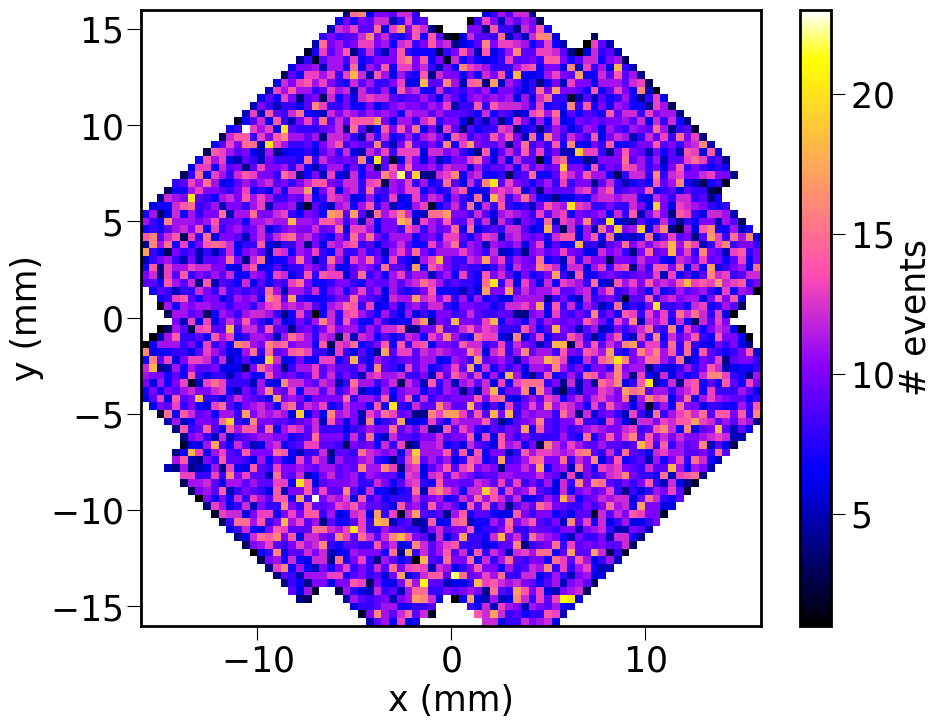

In [8]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

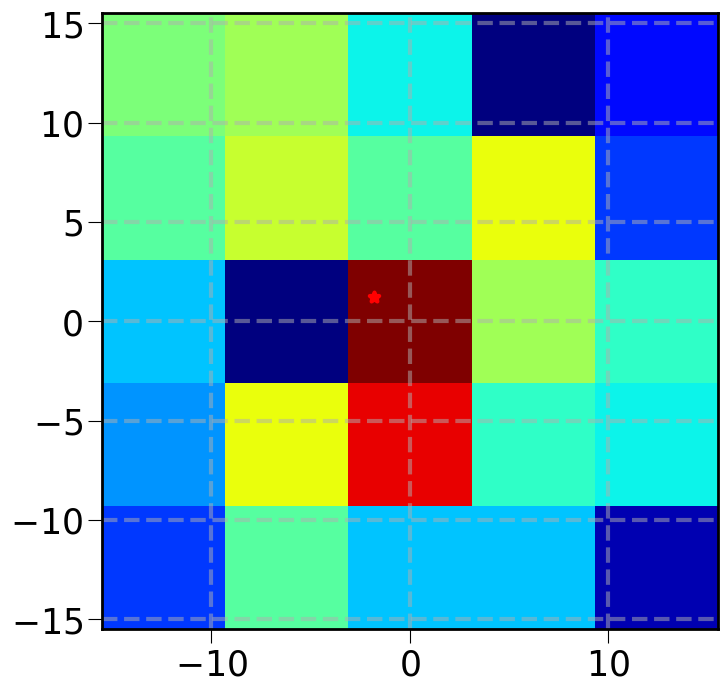

In [9]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extent(), cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.grid()

# Barycenter

In [10]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y, nsipms)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [11]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422
1,-1.811872,-5.067580,-5.436801,-9.872460,-5.169864,11.270505,3.624929,4.804881,6.018886
2,-4.594245,7.181295,-4.175442,14.949836,-5.185869,15.521982,-0.418803,-7.768542,7.779822
3,-3.586973,-5.416092,-4.468119,-11.215580,-5.194487,12.072834,0.881145,5.799488,5.866044
4,5.321667,-4.753333,8.467725,-10.989602,-5.193743,13.873490,-3.146058,6.236268,6.984893
...,...,...,...,...,...,...,...,...,...
49995,-3.022500,4.417500,-6.660443,9.942701,-5.177174,11.967406,3.637943,-5.525201,6.615322
49996,-2.878571,-5.092857,-6.990251,-13.187381,-5.183974,14.925503,4.111679,8.094524,9.078944
49997,5.414480,-3.170136,12.537375,-6.681049,-5.166863,14.206414,-7.122896,3.510913,7.941168


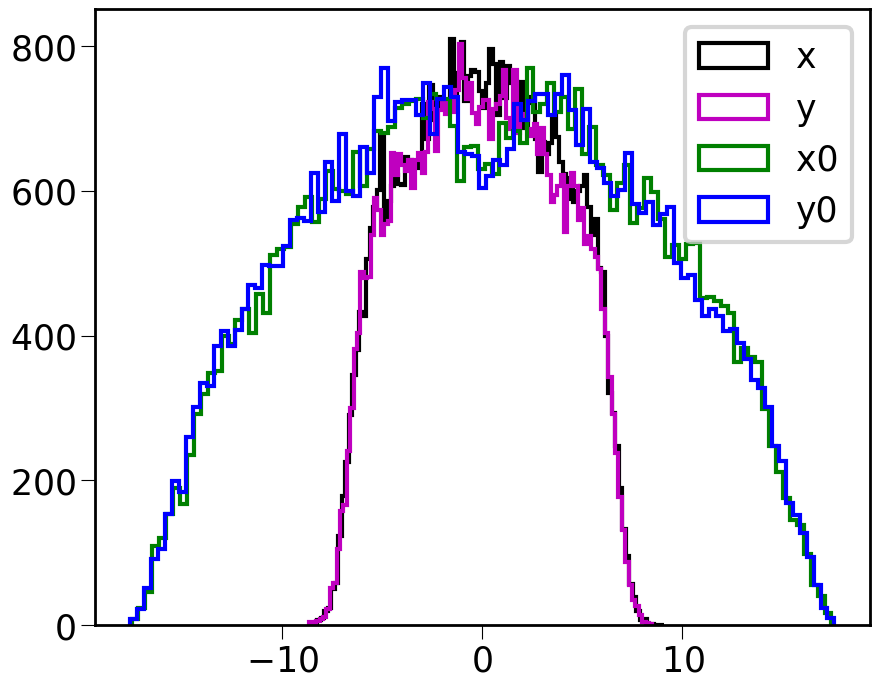

In [12]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

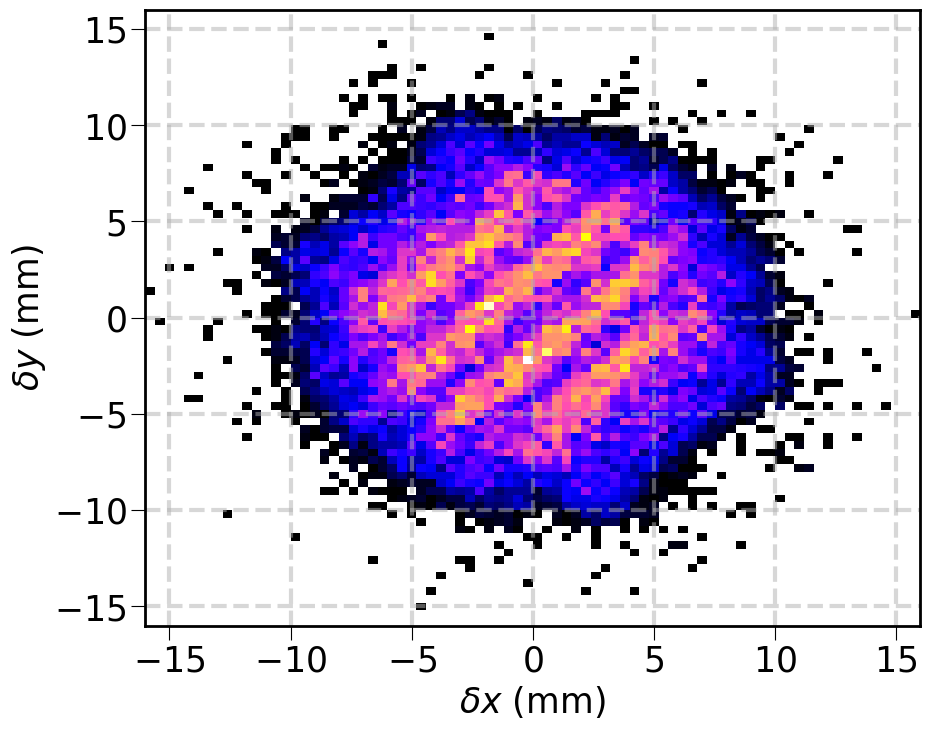

In [13]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

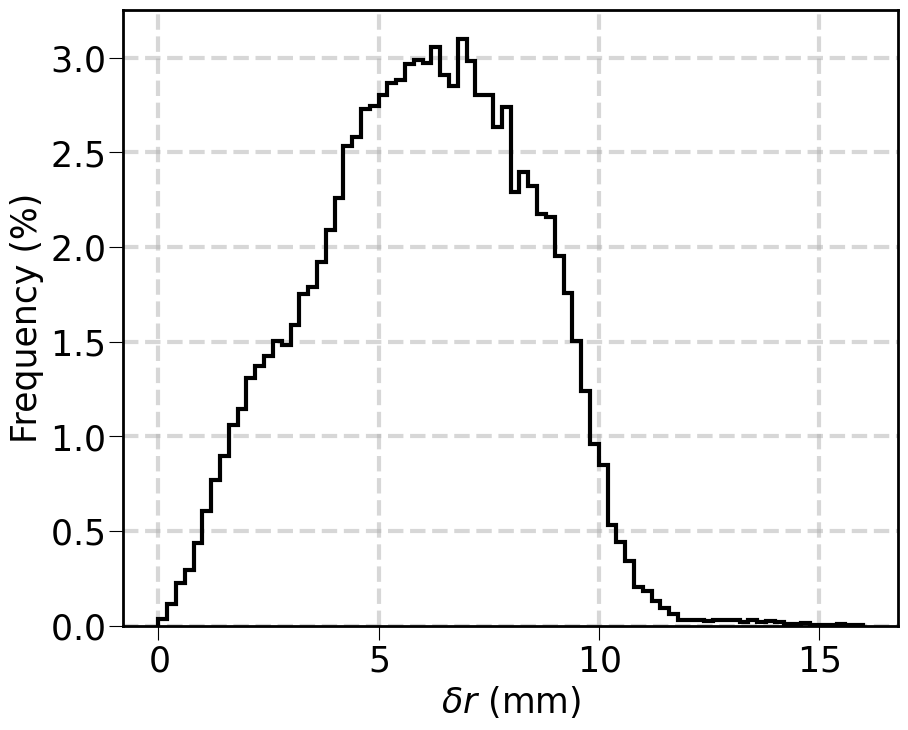

In [14]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

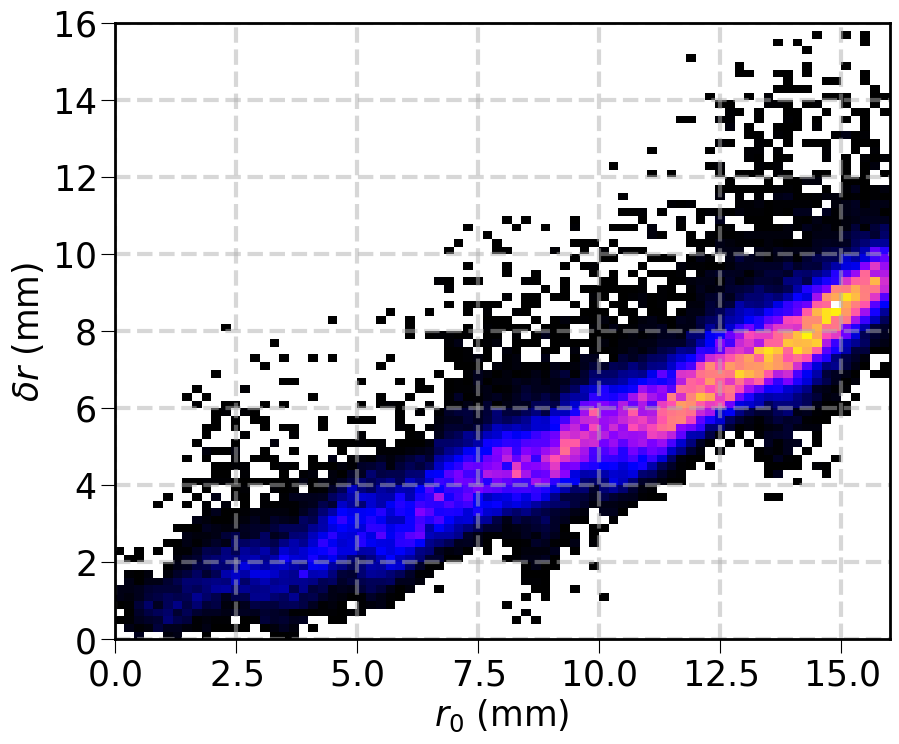

In [15]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

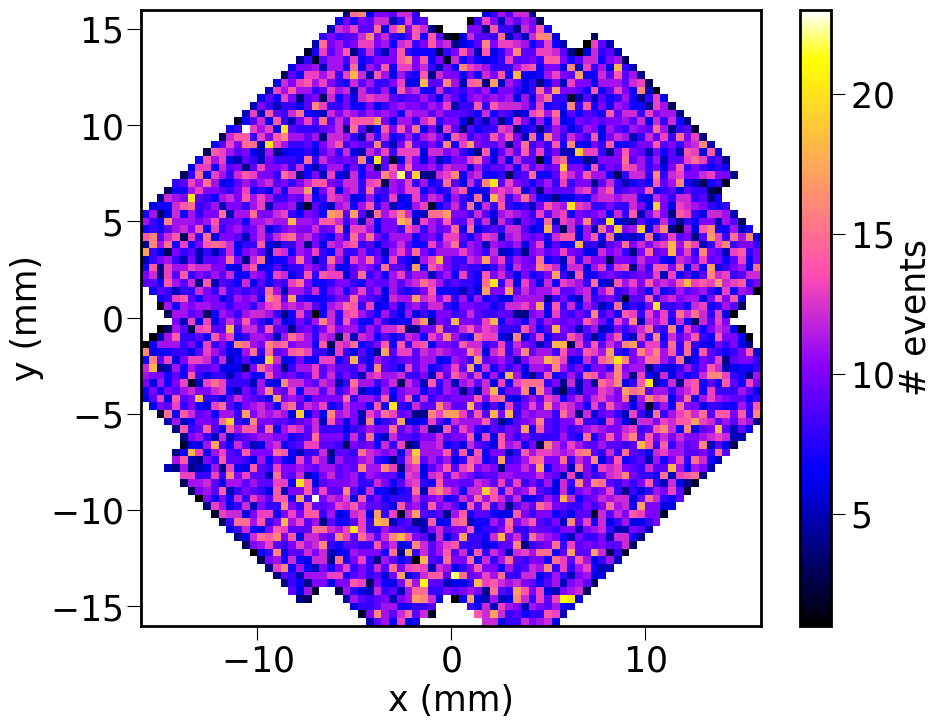

In [16]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

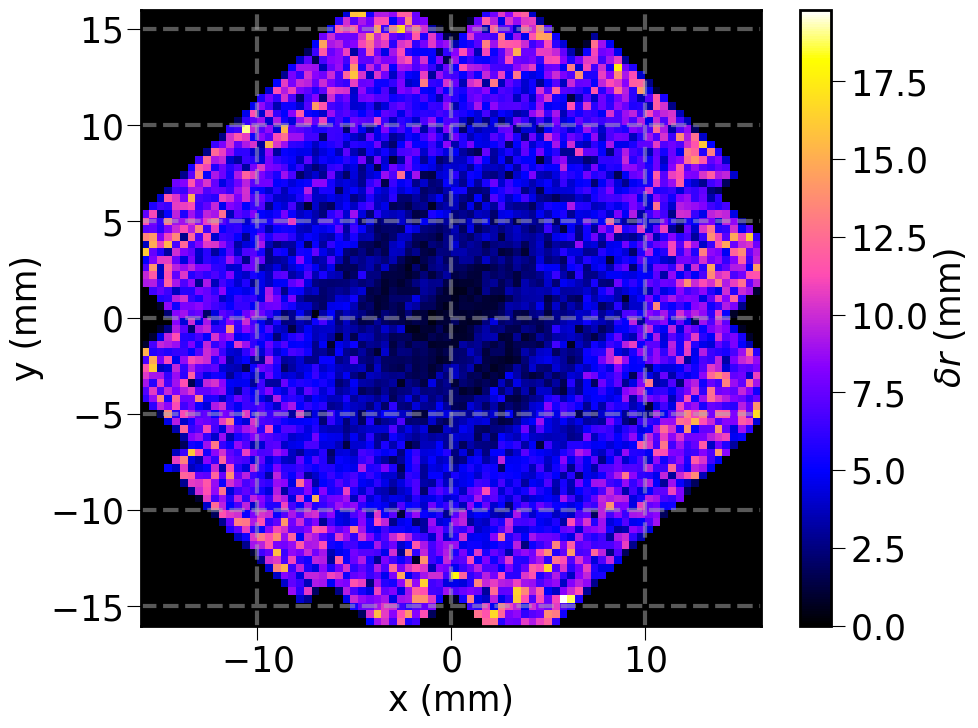

In [17]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

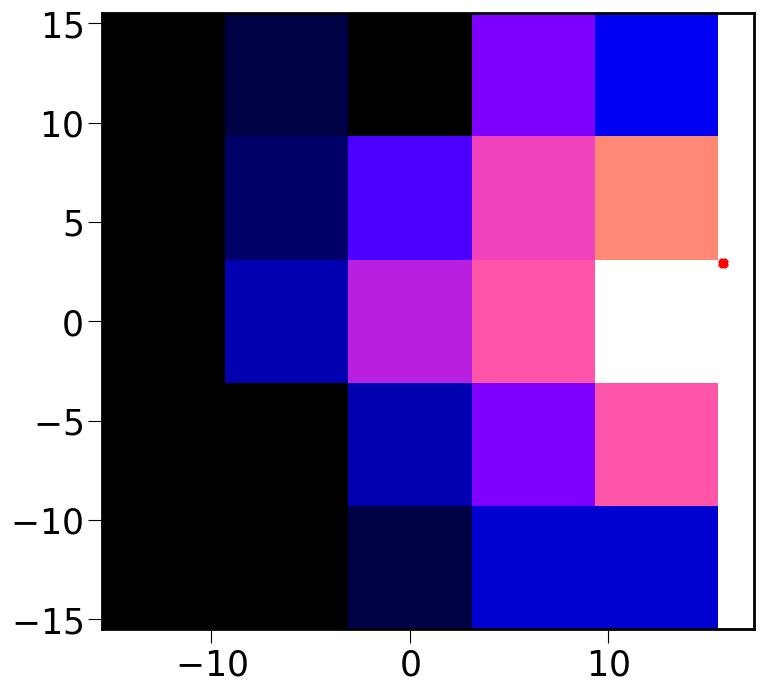

In [18]:
row = testdf.iloc[13]
img = row.image[0]
x   = row.x0
y   = row.y0
plt.imshow(img.T, origin="lower", extent=extent());
plt.scatter([x], [y], s=20, marker="X", color="r");

# NN

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

In [22]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [23]:
train     = pd.concat([read_file(filename) for filename in filenames[:5]])
test      = pd.concat([read_file(filename) for filename in filenames[5:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [24]:
model     = Linear(nsipms, nsipms)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.21 s/item | ETA 0.0 min | Ellapsed 1.8 min


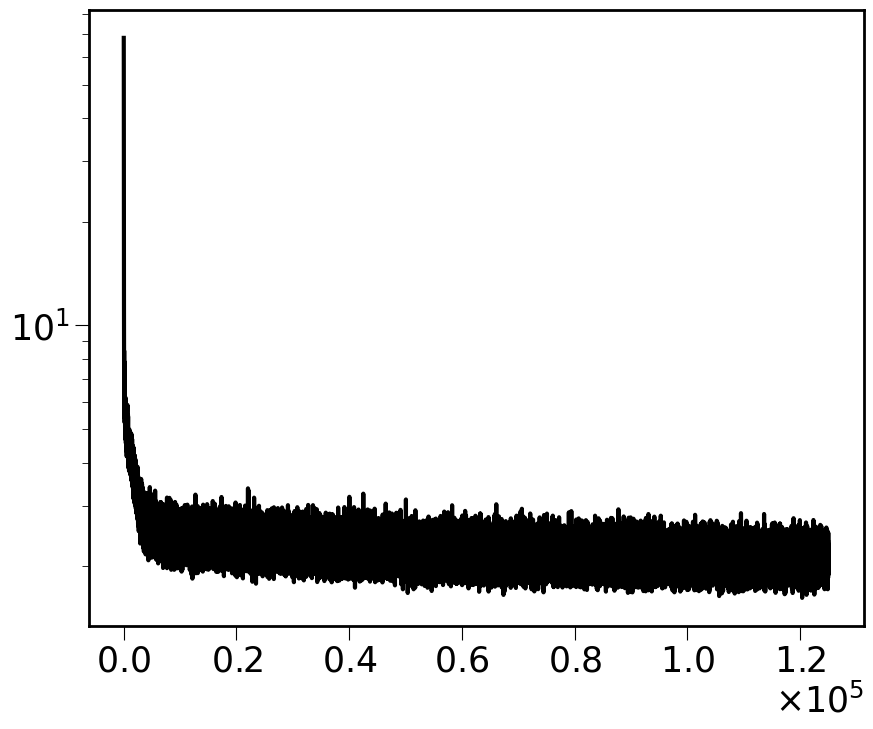

In [26]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [27]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

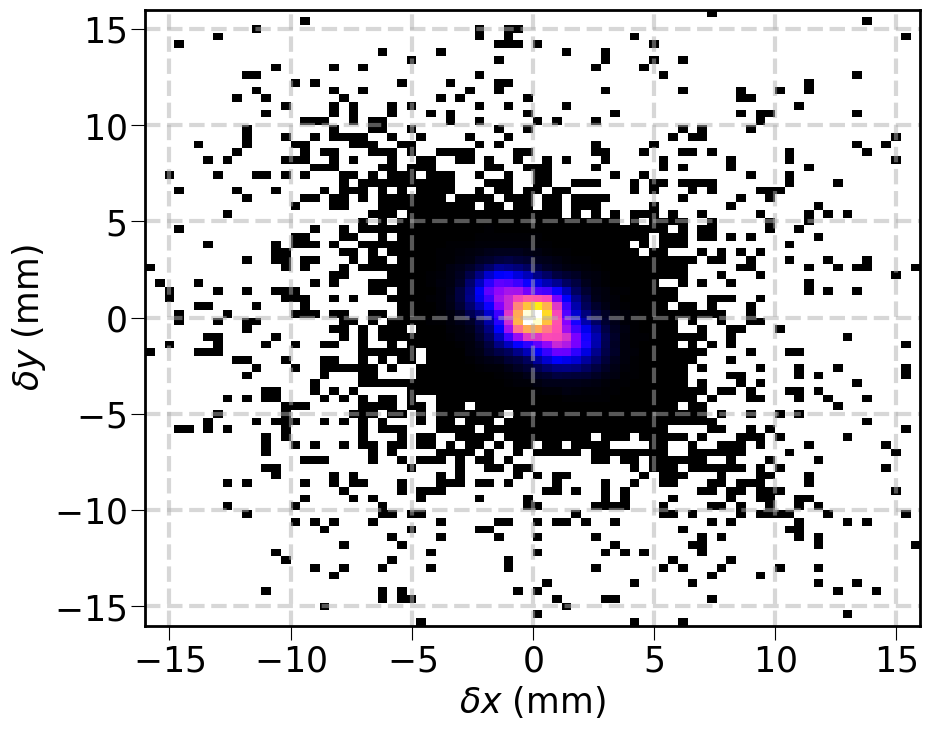

In [28]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

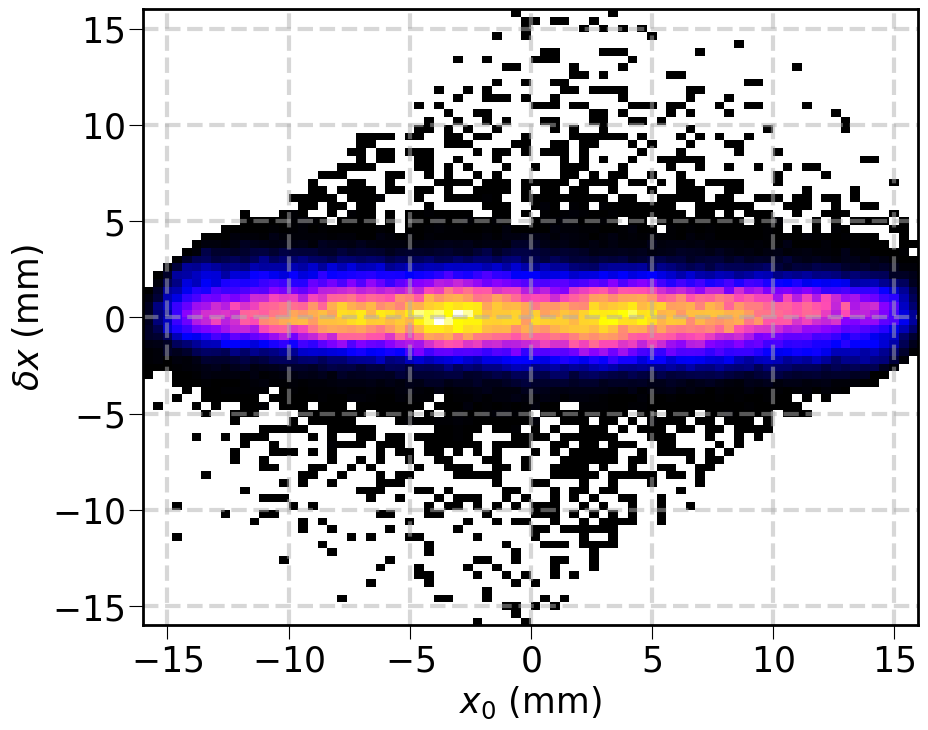

In [41]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_0$ (mm)")
plt.ylabel("$\delta x$ (mm)")
plt.grid()

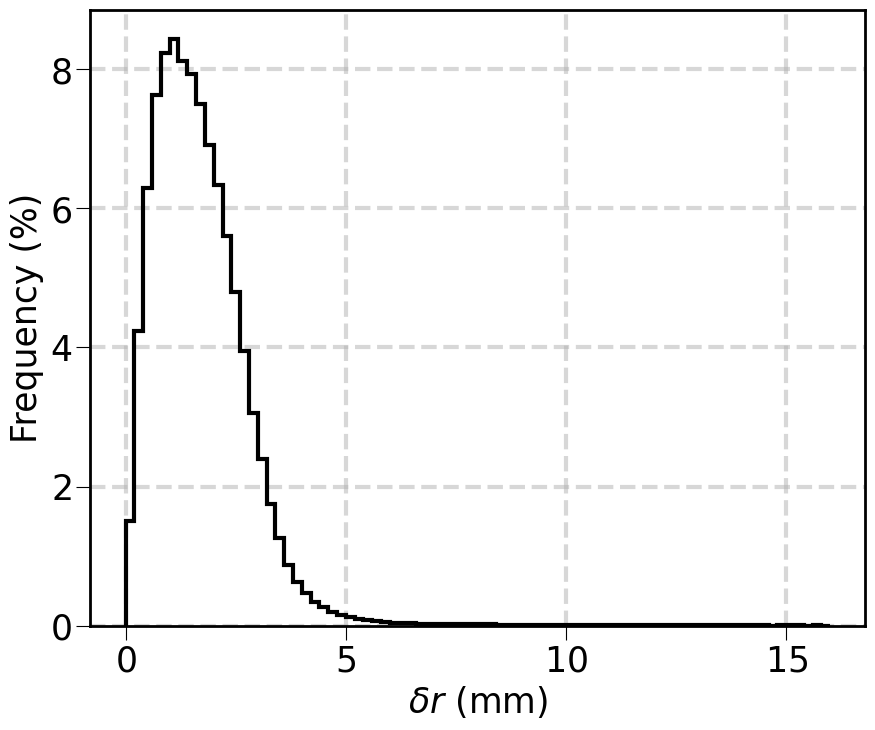

In [30]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

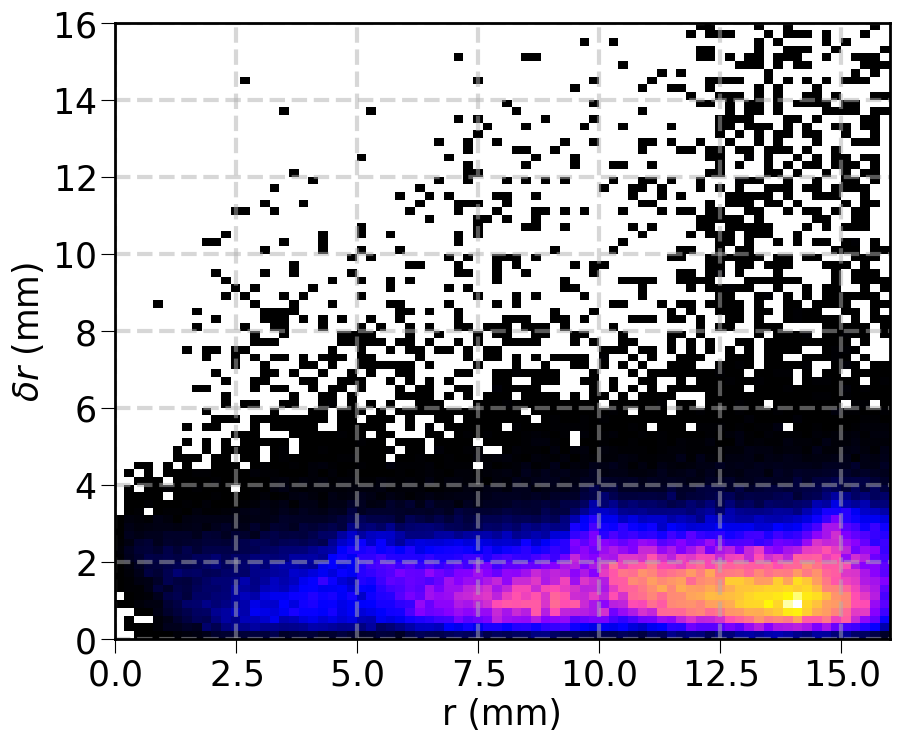

In [31]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

In [32]:
reco_bins  = np.arange(-16, 17.)
reco_error = (reco_nn.loc[lambda df: df.y.abs()<1]
                     .assign(rbin=lambda df: np.digitize(df.x, reco_bins))
                     .groupby("rbin")
                     .agg(r     = ("x", "mean"),
                          lower = ("dx", lambda x: np.percentile(x,  2.5)),
                          upper = ("dx", lambda x: np.percentile(x, 97.5)),
#                          lower = ("dx", lambda x: np.percentile(x, 15.86)),
#                          upper = ("dx", lambda x: np.percentile(x, 84.13)),
                         ))
reco_error.values

array([[-16.27258764,  -2.05250592,   0.05397396],
       [-15.36776144,  -1.7374886 ,   1.8452845 ],
       [-14.49752759,  -1.76040428,   2.82381003],
       [-13.47334534,  -2.20128508,   3.13482353],
       [-12.42977495,  -1.99212559,   3.02146893],
       [-11.45142829,  -1.9450315 ,   2.80733833],
       [-10.46311018,  -1.90378304,   2.97890685],
       [ -9.50129255,  -1.92933185,   3.2200381 ],
       [ -8.55329788,  -2.05436836,   3.32664602],
       [ -7.56375814,  -2.05475212,   3.66347524],
       [ -6.48939421,  -2.80694206,   2.82148794],
       [ -5.43061867,  -2.63952764,   2.1621175 ],
       [ -4.46455526,  -2.59619225,   2.32056194],
       [ -3.4920747 ,  -2.33413   ,   2.50045399],
       [ -2.54636643,  -2.18637278,   2.7436183 ],
       [ -1.55532242,  -2.90749261,   3.44313061],
       [ -0.5171509 ,  -3.99261112,   3.77286333],
       [  0.54110136,  -4.15900648,   4.03013487],
       [  1.54511787,  -3.1443587 ,   3.45578553],
       [  2.55396098,  -2.72261

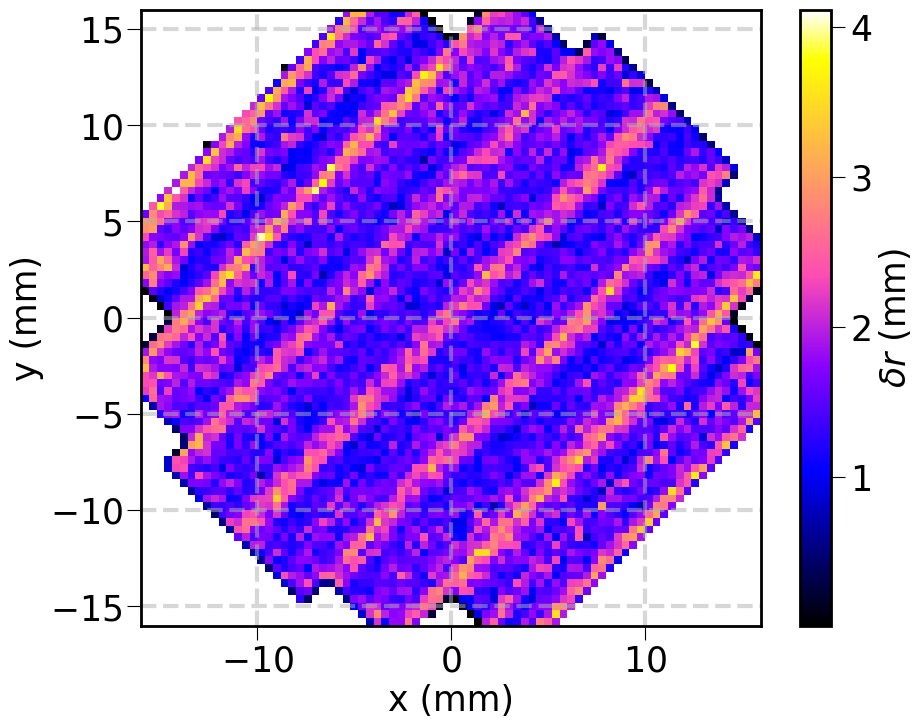

In [33]:
evt_per_bin = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
evt_per_bin = evt_per_bin[evt_per_bin>0].mean()
plt.hist2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr/evt_per_bin, cmin=1e-3)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

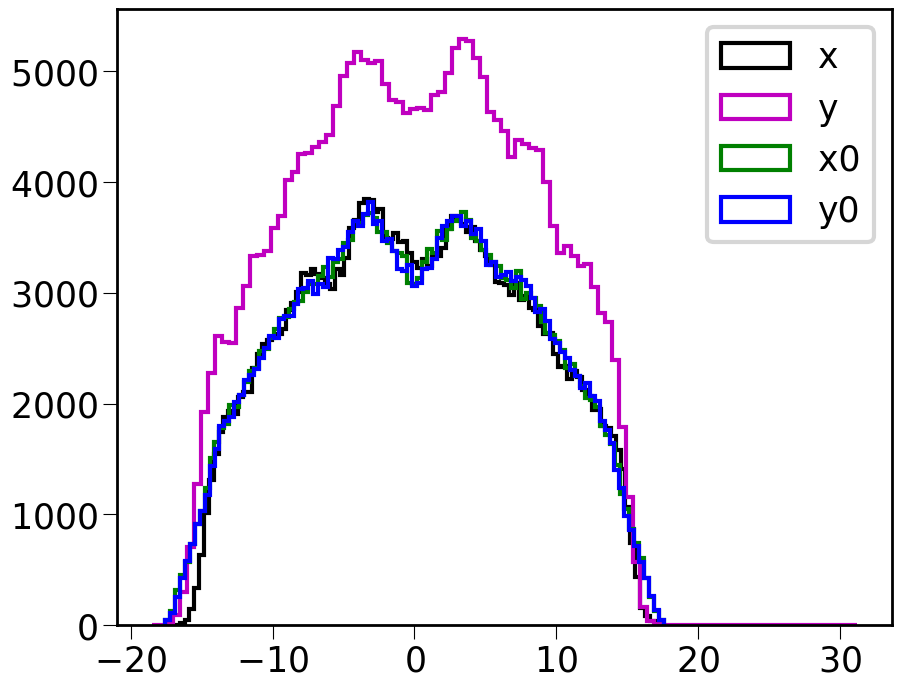

In [34]:
plt.hist(reco_nn.x , 101, histtype="step", label="x");
plt.hist(reco_nn.y , 101, histtype="step", label="y");
plt.hist(reco_nn.x0, 101, histtype="step", label="x0");
plt.hist(reco_nn.y0, 101, histtype="step", label="y0");
plt.legend()

In [35]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,8.542599,-7.753989,11.536913,9.019002,-7.830596,0.476403,-0.076607,0.482523
1,10.967795,6.876361,12.945149,11.292584,7.722267,0.324789,0.845906,0.906115
2,-5.777673,-9.225534,10.885402,-3.366726,-9.007110,2.410946,0.218424,2.420820
3,-2.443935,4.151040,4.817048,-0.877265,1.966334,1.566669,-2.184706,2.688381
4,-4.306371,-9.511055,10.440546,-5.422116,-10.691756,-1.115745,-1.180701,1.624482
...,...,...,...,...,...,...,...,...
49995,7.509577,4.776045,8.899683,7.548976,4.788091,0.039399,0.012047,0.041199
49996,-4.315569,5.024103,6.623122,-5.354178,5.814691,-1.038609,0.790588,1.305273
49997,3.211472,12.707440,13.106967,5.760730,11.444305,2.549258,-1.263135,2.845035


In [36]:
reco = pd.DataFrame.join( reco_bb
                        , reco_nn.drop(columns="x0 y0 r0".split())
                        , lsuffix="_bb"
                        , rsuffix="_nn")

In [37]:
reco

,x_bb,y_bb,x0,y0,z0,r0,dx_bb,dy_bb,dr_bb,x_nn,y_nn,dx_nn,dy_nn,dr_nn
event,,,,,,,,,,,,,,
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422,9.019002,-7.830596,0.476403,-0.076607,0.482523
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422,12.428401,1.453131,-0.731959,0.398264,0.833293
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422,2.449215,13.921917,-0.081112,0.326950,0.336861
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422,-7.313646,10.877753,4.110105,3.519747,5.411246
0,7.002353,1.860000,16.436859,3.484968,-5.177589,16.802242,-9.434506,-1.624968,9.573422,12.890188,-6.937481,0.528722,-0.188359,0.561272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49999,-4.993774,2.774319,-12.421802,8.193824,-5.189029,14.880858,7.428028,-5.419505,9.194925,0.985224,-2.084099,2.673192,10.156899,10.502787
49999,-4.993774,2.774319,-12.421802,8.193824,-5.189029,14.880858,7.428028,-5.419505,9.194925,10.995810,2.199247,-2.490344,2.685898,3.662766
49999,-4.993774,2.774319,-12.421802,8.193824,-5.189029,14.880858,7.428028,-5.419505,9.194925,2.934507,1.219787,-0.108588,-0.285292,0.305259


In [38]:
reco.to_hdf(output, key="/data", complib="zlib", complevel=4)

NameError: name 'output' is not defined

In [ ]:
normhist(reco.x0  , 101, histtype="step", label="x$_{true}$");
normhist(reco.y0  , 101, histtype="step", label="y$_{true}$");
normhist(reco.x_bb, 101, histtype="step", label="x$_{B}$");
normhist(reco.y_bb, 101, histtype="step", label="y$_{B}$");
normhist(reco.x_nn, 101, histtype="step", label="x$_{NN}$");
normhist(reco.y_nn, 101, histtype="step", label="y$_{NN}$");
plt.legend()
plt.xlabel("x,y (mm)")
plt.ylabel("Frequency (%)")
plt.grid()